In [1]:
print("kmeans-vs-spectral-clustering")

kmeans-vs-spectral-clustering


In [2]:
#Imports
import numpy as np
import matplotlib.pyplot as plt

In [4]:
k=0
data=np.zeros((373,2))
out=np.zeros(373)
with open ("dataset.txt",'r') as f:
  p=f.readlines() #Read data line by line stored in lists
  for i in p:
    l=i.split() #split lines based on space
    for j in range(2):
      data[k][j]=float(l[j]) #typecasting
    out[k]=float(l[2]) #storing output
    k=k+1
print("Data Extracted")

Data Extracted


In [5]:
def cluster(X,mu1,mu2): #defining functions to create clusters
  #empty clusters
  c1=[]
  c2=[]
  for i in range(np.shape(X)[0]):
    l1=np.linalg.norm(X[i]-mu1) #findnorm from first representative
    l2=np.linalg.norm(X[i]-mu2) #find norm from second representative
    #condition to define in to groups based on minimum distance
    if l1<l2:
      c1.append(X[i])
    else:
      c2.append(X[i])
  #convert to numpy array
  c1=np.array(c1)
  c2=np.array(c2)
  return c1,c2

In [6]:
def rep(c1,c2): #defining functions to select Group Representatives based on given clusters
#finding mean point of all clusters
  mu1=np.array([np.mean(c1[:,0]),np.mean(c1[:,1])])
  mu2=np.array([np.mean(c2[:,0]),np.mean(c2[:,1])])
  return mu1,mu2

In [7]:
#initialize points
idx = np.random.choice(data.shape[0], size=2, replace=False) #randomly select cluster representative indices
mu_1 = data[idx[0]]
mu_2 = data[idx[1]]

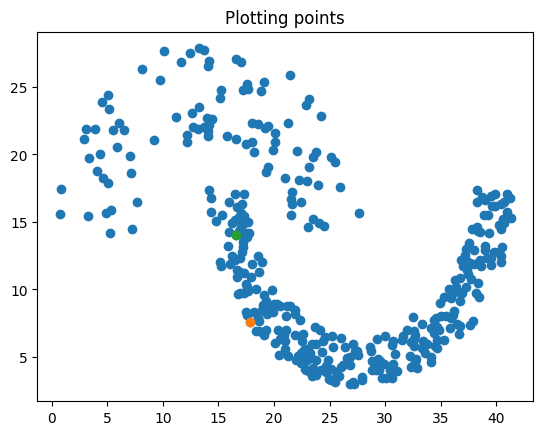

In [8]:
plt.scatter(data[:,0],data[:,1]) #Plotting points with the cluster reprersentatives
plt.scatter(mu_1[0],mu_1[1])
plt.scatter(mu_2[0],mu_2[1])
plt.title(label="Plotting points")
plt.show()

In [9]:
#K-Means Clustering
#run to find actual clusters and cluster representatives.
#K-Clustering
for i in range(10):
  k=cluster(data,mu_1,mu_2)
  mu_1,mu_2=rep(k[0],k[1])
c1=k[0]
c2=k[1]
print("Cluster Representatives: ",mu_1,mu_2)

Cluster Representatives:  [31.71540404  8.03737374] [15.97542857 16.79457143]


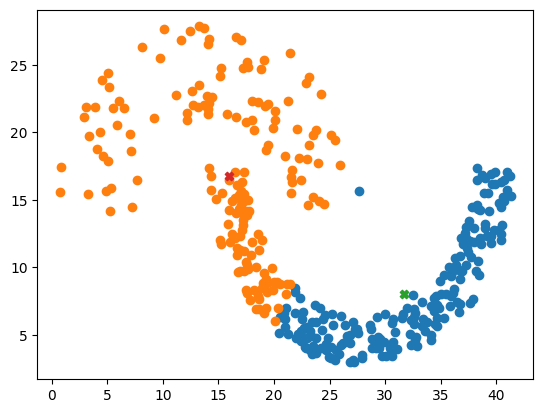

In [10]:
#Plot clusters after K-Means
plt.scatter(c1[:,0],c1[:,1])
plt.scatter(c2[:,0],c2[:,1])
plt.scatter(mu_1[0],mu_1[1],marker='X')
plt.scatter(mu_2[0],mu_2[1],marker='X')
plt.show()

In [11]:
#Seperating Output Clusters
cy1=[]
cy2=[]
#Create Clusters of output
for i in range(np.shape(data)[0]):
  if out[i]==1:
    cy2.append(data[i])
  else:
    cy1.append(data[i])

In [12]:
#find accuracy using given outputs
cor=0 #counter variable
total=np.shape(data)[0]
for i in range(np.shape(cy1)[0]):
  #conditional checking
  if cy1[i] in c1: #if point in cluster 1?
    cor=cor+1
for j in range(np.shape(cy2)[0]):
  if cy2[j] in c2: #if point in cluster 1?
    cor=cor+1
print("Accuracy",cor/total*100,"%")

Accuracy 38.337801608579085 %


In [13]:
#Spectral Cluster Functions
#Similaity Matrix using given formula
def similarity(X,sigma):
  w=np.zeros((np.shape(X)[0],np.shape(X)[0])) #define zero matrix
  for i in range(np.shape(X)[0]):
    for j in range(i+1,np.shape(X)[0]): #to avoid i=j condition
      if w[i][j]==0:
        w[i][j]=np.exp(-((np.linalg.norm(X[i]-X[j]))**2)/sigma) #replace zero with given formula
        w[j][i]=w[i][j] #create a symmetric matrix
  return w

In [14]:
#create degree matrix
def degree(X,w):
  degree=np.zeros((np.shape(X)[0],np.shape(X)[0])) #Zero Matrix to store diagonal values
  for i in range(np.shape(X)[0]):
    sum=0 #counter
    for j in range(np.shape(X)[0]):
      sum=sum+w[i][j] #Sum weights
    degree[i][i]=sum #replace at diagonals
  return degree

In [15]:
#Define Laplacian Matrix
def laplacian(X,sigma):
  W=similarity(X,sigma) #call similarity matrix to create W
  D=degree(X,W) #Call degree function to create D
  L=D-W  #find Laplacian L=D-W
  return L
lap=laplacian(data,1) #Call laplacian keeping sigma 1 [ideal]
print(lap)

[[ 3.23678909e-02 -3.23060745e-02 -4.52865717e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.23060745e-02  3.37724289e-02 -1.46631915e-03 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-4.52865717e-05 -1.46631915e-03  9.33893404e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  1.74976054e+00
  -1.78619042e-01 -6.00546679e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.78619042e-01
   4.38150641e+00 -8.43664817e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -6.00546679e-02
  -8.43664817e-01  3.98130144e+00]]


In [16]:
#Spectral Clustering
#Decompose Laplacian to Eigen Vectors in ascending order of eigen values
def decompose(L):
  D,Vec=np.linalg.eig(L) #decompose
  idx=np.argsort(D) #sort and fetch indices
  #sort using sorted indices
  Vec=Vec[:,idx]
  D=D[idx]
  #create diagonal matrix of eigen values
  D=np.diag(D)
  return Vec,D
vec,D=decompose(lap) #fetch Eigen Vectors of Laplacian Matrix
print("Eigen Vectors:\n",vec,"\n","Eigen Values Diagonal Matrix:\n",D)

Eigen Vectors:
 [[ 5.17780373e-02 -1.55009147e-01 -1.30113339e-01 ... -1.36106851e-16
   6.41415547e-16 -1.30368571e-16]
 [ 5.17780373e-02 -1.54912648e-01 -1.29886427e-01 ...  3.71793928e-16
  -1.29456916e-18  2.34569735e-16]
 [ 5.17780373e-02 -1.50459307e-01 -1.19422052e-01 ...  1.06700819e-17
  -4.79088764e-16  3.33950806e-16]
 ...
 [ 5.17780373e-02  2.80610422e-02 -1.29080044e-02 ...  3.07726117e-18
  -1.51467082e-23 -1.06546847e-19]
 [ 5.17780373e-02  2.80608057e-02 -1.29076996e-02 ...  2.64419656e-18
  -7.59158632e-23 -2.54715371e-20]
 [ 5.17780373e-02  2.80608629e-02 -1.29077734e-02 ...  2.14860021e-18
  -4.58403300e-23 -9.14176534e-20]] 
 Eigen Values Diagonal Matrix:
 [[1.73352530e-15 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.20296865e-05 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.16989361e-05 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e

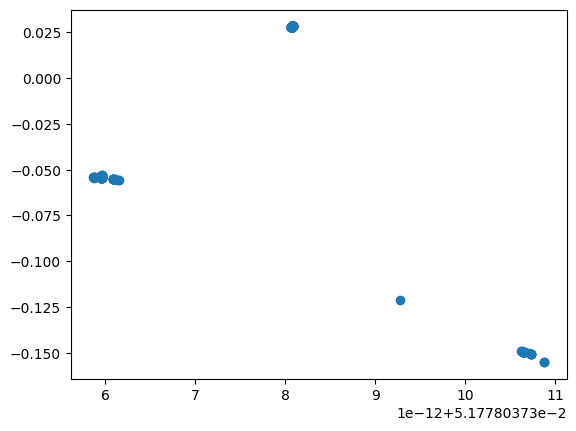

From Visual inspection of the graph we can say that these points are linearly seperable


In [17]:
#Spectral Clustering
H=vec[:,:2] #Choose k smallest vectors
plt.scatter(H[:,0],H[:,1])
plt.show()
print("From Visual inspection of the graph we can say that these points are linearly seperable")

[ 0.05177804 -0.07946297] [0.05177804 0.0279272 ]


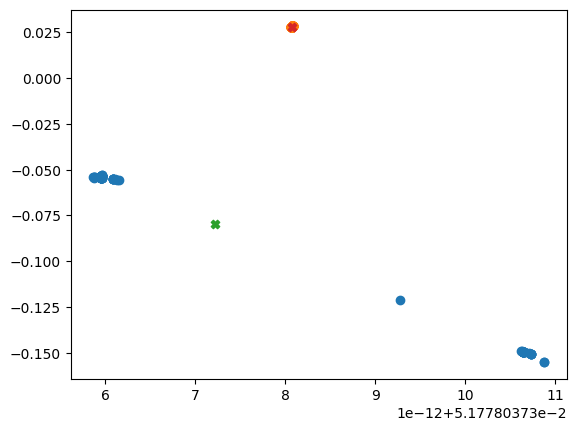

In [18]:
#Spectral Clustering
idx = np.random.choice(H.shape[0], size=2, replace=False) #randomly select cluster representative indices
mu_1 = H[idx[0]]
mu_2 = H[idx[1]]
#run K-Means Clustering on the Eigen Vectors
for i in range(100):
  k=cluster(H,mu_1,mu_2)
  mu_1,mu_2=rep(k[0],k[1])
#Final Clusters of eigen vectors
c1=k[0]
c2=k[1]
print(mu_1,mu_2)
#plot clusters of eigen vectors
plt.scatter(c1[:,0],c1[:,1])
plt.scatter(c2[:,0],c2[:,1])
plt.scatter(mu_1[0],mu_1[1], marker='X')
plt.scatter(mu_2[0],mu_2[1],marker='X')
plt.show()

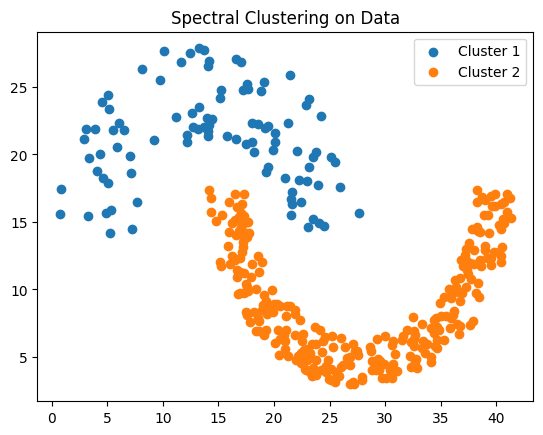

In [19]:
#Connect spectral embeddings to actual data
labels = np.zeros(H.shape[0], dtype=int) #zero matrix to store all cluster labels
labels[np.isin(H, c2).all(axis=1)] = 1 #if points in H are in c2 then mark those indices in labels as 1 let c1 labels be 0
cluster1 = data[labels == 0] #those indices in data where the label indices are 0 belong to cluster 1
cluster2 = data[labels == 1] #those indices in data where the label indices are 1 belong to cluster 2
#Plot Spectral Clusters
plt.scatter(cluster1[:, 0], cluster1[:, 1], label='Cluster 1')
plt.scatter(cluster2[:, 0], cluster2[:, 1], label='Cluster 2')
plt.legend()
plt.title("Spectral Clustering on Data")
plt.show()

In [20]:
#find accuracy using given dataset
cor=0 #counter variable
total=np.shape(data)[0]
for i in range(np.shape(cy1)[0]):
  #conditional checking
  if cy1[i] in cluster1: #if point in cluster 1?
    cor=cor+1
for j in range(np.shape(cy2)[0]):
  if cy2[j] in cluster2: #if point in cluster 2?
    cor=cor+1
print("Accuracy",cor/total*100,"%")

Accuracy 100.0 %


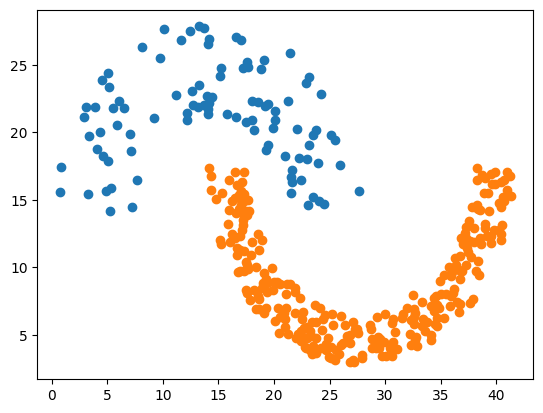

In [22]:
#Plotting original output points as per dataset to compare
cy1=np.array(cy1)
cy2=np.array(cy2)
plt.scatter(cy1[:,0],cy1[:,1])
plt.scatter(cy2[:,0],cy2[:,1])
plt.show()